# Data Science Course Cirriculum Development
1. Preprocess data

In [2]:
import numpy as np
import pandas as pd
import os
import requests
import matplotlib as plt
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
## Machine Learning libraries
from sklearn.preprocessing import normalize
import scipy.cluster.hierarchy as sch
from scipy import zeros as sci_zeros
from scipy.spatial.distance import euclidean
from scipy.cluster.hierarchy import ClusterWarning
from warnings import simplefilter
simplefilter("ignore", ClusterWarning)

In [4]:
filename_data = 'C:/Users/floro/L-Documents/Mitacs WebScraping Paper/Supplemental_Python_Remote.csv'

## Read csv file (dataset)
results = pd.read_csv(filename_data)

# Change column names
results.rename(columns={'Job_Title': 'Title', 'Company_Name': 'Company', 'Job_Description': 'Descriptions'}, inplace=True)

results.head()

,Title,Company,Location,Rating,Date,Salary,Description,Links,Descriptions,Combined
0,Python Developer,LookFar Labs,Remote,NaN,5 days ago,"$110,000 - $135,000 a year",NaN,https://www.indeed.com/pagead/clk?mo=r&ad=-6NY...,We put patents into business context. In essen...,Python Developer We put patents into business ...
1,Software Engineer (Python & PySpark),Emergent Software,Remote,NaN,NaN,"$110,000 - $145,000 a year",NaN,https://www.indeed.com/pagead/clk?mo=r&ad=-6NY...,** This is a direct hire position for one of o...,Software Engineer (Python & PySpark) ** This i...
2,Entry Level Technician,"Mr. Elmer, LLC",Remote,NaN,5 days ago,$30 - $35 an hour,NaN,https://www.indeed.com/pagead/clk?mo=r&ad=-6NY...,Position Overview:\nWe seek a motivated Entry ...,Entry Level Technician Position Overview:\nWe ...
3,Epidemiologist II (Python & SAS),Tanaq Support Services LLC,Remote,NaN,5 days ago,NaN,NaN,https://www.indeed.com/pagead/clk?mo=r&ad=-6NY...,Description:Overview\nTanaq Support Services (...,Epidemiologist II (Python & SAS) Description:O...
4,Data Analyst - OPT EAD only (No H1B's),SR SOFT LLC,Remote,NaN,5 days ago,"$74,677 - $81,134 a year",NaN,https://www.indeed.com/pagead/clk?mo=r&ad=-6NY...,```Job Summary```\nWe are seeking a skilled Da...,Data Analyst - OPT EAD only (No H1B's) ```Job ...


In [5]:
# Check for missing values in the columns
missing_values = results.isnull().sum()

# Display the number of missing values for each column
missing_values

Title              0
Company            0
Location           0
Rating          4041
Date              13
Salary          3247
Description     1950
Links              0
Descriptions    2091
Combined           0
dtype: int64

# Import OpenAI library and load API keys

In [6]:
try:
    import openai
except:
    !pip install openai
    import openai

In [7]:
## API Key
API_KEY= "REDACTED"

os.environ['OPENAI_API_KEY'] = API_KEY
openai.api_key = os.getenv("OPENAI_API_KEY")

In [8]:
# OpenAI API parameters
# model = "gpt-3.5-turbo-0125" # 16K tokens
# model = "gpt-3.5-turbo" # 4K tokens
# model = "gpt-4" # 8K tokens
model = "gpt-4-0125-preview" # 128K tokens

In [14]:
pip install --upgrade openai

     ---------------------------------------- 0.0/320.1 kB ? eta -:--:--
     ------------------------------------- 320.1/320.1 kB 10.0 MB/s eta 0:00:00
     ---------------------------------------- 0.0/409.3 kB ? eta -:--:--
     ------------------------------------- 409.3/409.3 kB 12.9 MB/s eta 0:00:00
     ---------------------------------------- 0.0/75.6 kB ? eta -:--:--
     ---------------------------------------- 75.6/75.6 kB 4.1 MB/s eta 0:00:00
     ---------------------------------------- 0.0/77.9 kB ? eta -:--:--
     ---------------------------------------- 77.9/77.9 kB ? eta 0:00:00
     ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
     ------------ --------------------------- 0.6/1.9 MB 12.9 MB/s eta 0:00:01
     ------------------------ --------------- 1.2/1.9 MB 12.4 MB/s eta 0:00:01
     ------------------------------------ --- 1.7/1.9 MB 12.2 MB/s eta 0:00:01
     ---------------------------------------  1.9/1.9 MB 10.1 MB/s eta 0:00:01
     -----

In [9]:
from openai import OpenAI
client = OpenAI()

In [10]:
response = client.chat.completions.create(
    model=model,
    messages=[
        {"role": "system", "content": "You are a helpful assistant."}, # context
        {"role": "user", "content": "Give me 30 most important technical skills " + \
         "for a remote data scientist job without explanation (e.g.: Python, SQL). " + \
         "And categorize them into these four categories: (1) Programming/systems skills (2) Technical, data-related, modeling/algorithms skills " + \
         "Display skills using 2 lists separately."} # prompt
    ]
)

print(response.choices[0].message.content)

Certainly! Here are the lists categorized as requested:

### (1) Programming/Systems Skills
1. Python
2. R
3. SQL
4. Java
5. Scala
6. Bash/Shell scripting
7. Git/version control
8. Docker
9. Kubernetes
10. Cloud computing platforms (AWS, Azure, GCP)

### (2) Technical, Data-Related, Modeling/Algorithms Skills
1. Statistical analysis
2. Machine Learning
3. Deep Learning
4. Natural Language Processing (NLP)
5. Computer Vision
6. Time Series Analysis
7. Data Visualization (e.g., Tableau, PowerBI, Matplotlib, Seaborn)
8. Big Data Technologies (e.g., Hadoop, Spark)
9. Data Wrangling (e.g., Pandas, NumPy)
10. Model deployment and scalability (e.g., TensorFlow Serving, Flask for API design)


# Extract skills from job postings
Use combination of skills manually generated and from chatGPT response

In [11]:
# Manually create a list of keywords/key-phrases (N-grams) that represent skills

## Programming/systems skills
sskills = {}
sskills['Python'] = []
sskills['SQL'] = []
sskills['Tableau'] = []
sskills['Power BI'] = []
sskills['Hadoop'] = []
sskills['Spark'] = []

## Technical, data-related, modeling/algorithms skills
tskills = {}
tskills ['Data Management'] = []
tskills['Machine Learning'] = []
tskills['Deep Learning'] = []
tskills['Natural Language Processing (NLP)'] = []
tskills['Statistical Analysis'] = []
tskills['Data Visualization'] = [] # (e.g., Tableau, PowerBI, Matplotlib, Seaborn, ggplot2)
tskills['Big Data'] = [] # Hadoop, Spark
tskills['Scikit-Learn'] = []
tskills['PyTorch'] = []
tskills['TensorFlow'] = []
tskills['Data Analytics'] = []
tskills['Modeling'] = []
tskills['Pandas'] = []
tskills['NumPy'] = []
tskills ['Data Warehousing'] = []

## Business intelligence, project management, consulting, negotiation skills
bskills = {}
bskills['Project Management'] = [] # (e.g., (e.g., Agile, Scrum))
bskills['Consulting']  = []
bskills['Negotiation Skills'] = []
bskills['Business Intelligence'] = []

## Teamwork and communication skills
pskills = {}
pskills['Teamwork'] = []
pskills['Creativity'] = []
pskills['Communication'] = []
pskills['Problem-Solving'] = []

## Extract skills from job postings
for ir, dfr in results.iterrows():
    cleantext = str(dfr["Descriptions"])

    # sskills: Programming/systems skills
    if("python" in cleantext.lower()):
        sskills['Python'].append('1')
    else:
        sskills['Python'].append('0')

    if("sql" in cleantext.lower()) or ("structured quer" in cleantext.lower()):
        sskills['SQL'].append('1')
    else:
        sskills['SQL'].append('0')

    if("tableau" in cleantext.lower()):
        sskills['Tableau'].append('1')
    else:
        sskills['Tableau'].append('0')

    if("powerbi" in cleantext.lower()) or ("power bi" in cleantext.lower()):
        sskills['Power BI'].append('1')
    else:
        sskills['Power BI'].append('0')

    if("hadoop" in cleantext.lower()):
        sskills['Hadoop'].append('1')
    else:
        sskills['Hadoop'].append('0')

    if("spark" in cleantext.lower()):
        sskills['Spark'].append('1')
    else:
        sskills['Spark'].append('0')

    # tskills: Technical, data-related, modeling/algorithms skills
    if("databas" in cleantext.lower()) or ("data mana" in cleantext.lower()) or ("data ha" in cleantext.lower()) or \
    ("data lake" in cleantext.lower()) or ("data war" in cleantext.lower()) or ("data eng" in cleantext.lower())  or ("data proc" in cleantext.lower()):
        tskills['Data Management'].append('1')
    else:
        tskills['Data Management'].append('0')

    if("machine learning" in cleantext.lower()):
        tskills['Machine Learning'].append('1')
    else:
        tskills['Machine Learning'].append('0')

    if("deep learning" in cleantext.lower()) or ("neural networks" in cleantext.lower()) or ("tensorflow" in cleantext.lower()) or ("pytorch" in cleantext.lower()):
        tskills['Deep Learning'].append('1')
    else:
        tskills['Deep Learning'].append('0')

    if("natural language processing" in cleantext.lower()) or ("nlp" in cleantext.lower()) or ("text analytics" in cleantext.lower()) or \
    ("sentiment analysis" in cleantext.lower()) or ("language model" in cleantext.lower()):
        tskills['Natural Language Processing (NLP)'].append('1')
    else:
        tskills['Natural Language Processing (NLP)'].append('0')

    if("statistics" in cleantext.lower()) or ("statistical" in cleantext.lower()) or ("regression" in cleantext.lower()):
        tskills['Statistical Analysis'].append('1')
    else:
        tskills['Statistical Analysis'].append('0')

    if("visualiz" in cleantext.lower()) or ("chart" in cleantext.lower()) or ("graph" in cleantext.lower()) or ("dashboard" in cleantext.lower()) or \
       ("tableau" in cleantext.lower()) or ("powerbi" in cleantext.lower()) or ("matplotlib" in cleantext.lower()) or \
        ("seaborn" in cleantext.lower()) or ("ggplot2" in cleantext.lower()):
        tskills['Data Visualization'].append('1')
    else:
        tskills['Data Visualization'].append('0')

    if("big data" in cleantext.lower()):
        tskills['Big Data'].append('1')
    else:
        tskills['Big Data'].append('0')

    if("scikit-learn" in cleantext.lower()) or ("sklearn" in cleantext.lower()):
        tskills['Scikit-Learn'].append('1')
    else:
        tskills['Scikit-Learn'].append('0')

    if("pytorch" in cleantext.lower()):
        tskills['PyTorch'].append('1')
    else:
        tskills['PyTorch'].append('0')

    if("tensorflow" in cleantext.lower()):
        tskills['TensorFlow'].append('1')
    else:
        tskills['TensorFlow'].append('0')

    if("data analysis" in cleantext.lower()) or ("data analytics" in cleantext.lower()):
        tskills['Data Analytics'].append('1')
    else:
        tskills['Data Analytics'].append('0')

    if("modeling technologies" in cleantext.lower()) or ("modeling technology" in cleantext.lower()) or ("modeling" in cleantext.lower()) or ("model" in cleantext.lower()):
        tskills['Modeling'].append('1')
    else:
        tskills['Modeling'].append('0')

    if("pandas" in cleantext.lower()):
        tskills['Pandas'].append('1')
    else:
        tskills['Pandas'].append('0')

    if("numpy" in cleantext.lower()):
        tskills['NumPy'].append('1')
    else:
        tskills['NumPy'].append('0')

    if("data warehousing" in cleantext.lower()):
        tskills['Data Warehousing'].append('1')
    else:
        tskills['Data Warehousing'].append('0')

    # bskills: Business intelligence, project management, consulting, negotiation skills
    if("project management" in cleantext.lower()) or ("agile" in cleantext.lower()) or ("scrum" in cleantext.lower()) or \
       ("kanban" in cleantext.lower()) or ("jira" in cleantext.lower()) or ("trello" in cleantext.lower()):
        bskills['Project Management'].append('1')
    else:
        bskills['Project Management'].append('0')

    if("consulting" in cleantext.lower()) or ("consultant" in cleantext.lower()):
        bskills['Consulting'].append('1')
    else:
        bskills['Consulting'].append('0')

    if("negotiation" in cleantext.lower()):
        bskills['Negotiation Skills'].append('1')
    else:
        bskills['Negotiation Skills'].append('0')

    if("business intelligence" in cleantext.lower()):
        bskills['Business Intelligence'].append('1')
    else:
        bskills['Business Intelligence'].append('0')

    # pskills: Teamwork and communication skills
    if("teamwork" in cleantext.lower()) or ("collaboration" in cleantext.lower()) or ("team player" in cleantext.lower()) or \
    ("collaborative work" in cleantext.lower()) or ("team-oriented" in cleantext.lower()):
        pskills['Teamwork'].append('1')
    else:
        pskills['Teamwork'].append('0')

    if("creativit" in cleantext.lower()) or ("creative" in cleantext.lower()) or ("creat" in cleantext.lower()):
        pskills['Creativity'].append('1')
    else:
        pskills['Creativity'].append('0')

    if("communication" in cleantext.lower()):
        pskills['Communication'].append('1')
    else:
        pskills['Communication'].append('0')

    if("problem-solving" in cleantext.lower()) or ("problem solver" in cleantext.lower()) or ("solve problems" in cleantext.lower()) or \
    ("critical thinking" in cleantext.lower()):
        pskills['Problem-Solving'].append('1')
    else:
        pskills['Problem-Solving'].append('0')



In [12]:
for skill, presence_list in tskills.items():
    print(f"{skill}: {len(presence_list)} entries")

Data Management: 4041 entries
Machine Learning: 4041 entries
Deep Learning: 4041 entries
Natural Language Processing (NLP): 4041 entries
Statistical Analysis: 4041 entries
Data Visualization: 4041 entries
Big Data: 4041 entries
Scikit-Learn: 4041 entries
PyTorch: 4041 entries
TensorFlow: 4041 entries
Data Analytics: 4041 entries
Modeling: 4041 entries
Pandas: 4041 entries
NumPy: 4041 entries
Data Warehousing: 4041 entries


In [13]:
## Create dataframe with extracted skills (1 if a skill was found in job description, 0 if a skills was not found in job description)
df1 = results[['Title', 'Company', 'Location', 'Descriptions']].copy()
df2 = pd.DataFrame(sskills)
df3 = pd.DataFrame(tskills)
df4 = pd.DataFrame(bskills)
df5 = pd.DataFrame(pskills)
frames = [df1, df2, df3, df4, df5]
res = pd.concat(frames, axis = 1)
res.head()

,Title,Company,Location,Descriptions,Python,SQL,Tableau,Power BI,Hadoop,Spark,...,NumPy,Data Warehousing,Project Management,Consulting,Negotiation Skills,Business Intelligence,Teamwork,Creativity,Communication,Problem-Solving
0,Python Developer,LookFar Labs,Remote,We put patents into business context. In essen...,1,1,0,0,0,1,...,0,0,1,0,0,0,0,1,1,0
1,Software Engineer (Python & PySpark),Emergent Software,Remote,** This is a direct hire position for one of o...,1,0,0,0,0,1,...,0,0,0,0,0,0,1,1,1,1
2,Entry Level Technician,"Mr. Elmer, LLC",Remote,Position Overview:\nWe seek a motivated Entry ...,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,1
3,Epidemiologist II (Python & SAS),Tanaq Support Services LLC,Remote,Description:Overview\nTanaq Support Services (...,1,0,0,0,0,0,...,0,0,0,0,0,0,1,1,1,1
4,Data Analyst - OPT EAD only (No H1B's),SR SOFT LLC,Remote,```Job Summary```\nWe are seeking a skilled Da...,1,1,1,1,0,0,...,0,0,1,0,0,0,0,0,0,0


In [14]:
## Save skills as 2D array
df = res.iloc[:,4:]
df_summary = df.apply(pd.to_numeric)
a = df_summary.values

print("Number of job postings:", a.shape[0])
print(a)

Number of job postings: 4041
[[1 1 0 ... 1 1 0]
 [1 0 0 ... 1 1 1]
 [1 0 0 ... 0 1 1]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


# Visualize key information

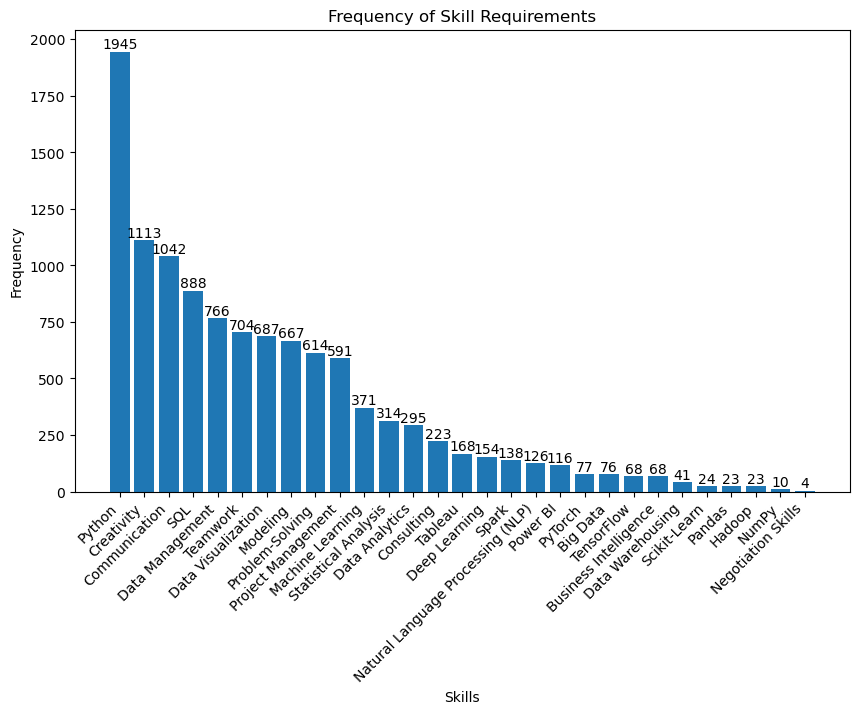

In [15]:
# Figure 1: A bar chart for the frequency of each skill requirement
skill_counts = df_summary.sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(skill_counts.index, skill_counts.values)

# Add numbers on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center')

plt.title('Frequency of Skill Requirements')
plt.ylabel('Frequency')
plt.xlabel('Skills')
plt.xticks(rotation=45, ha='right')
plt.show()

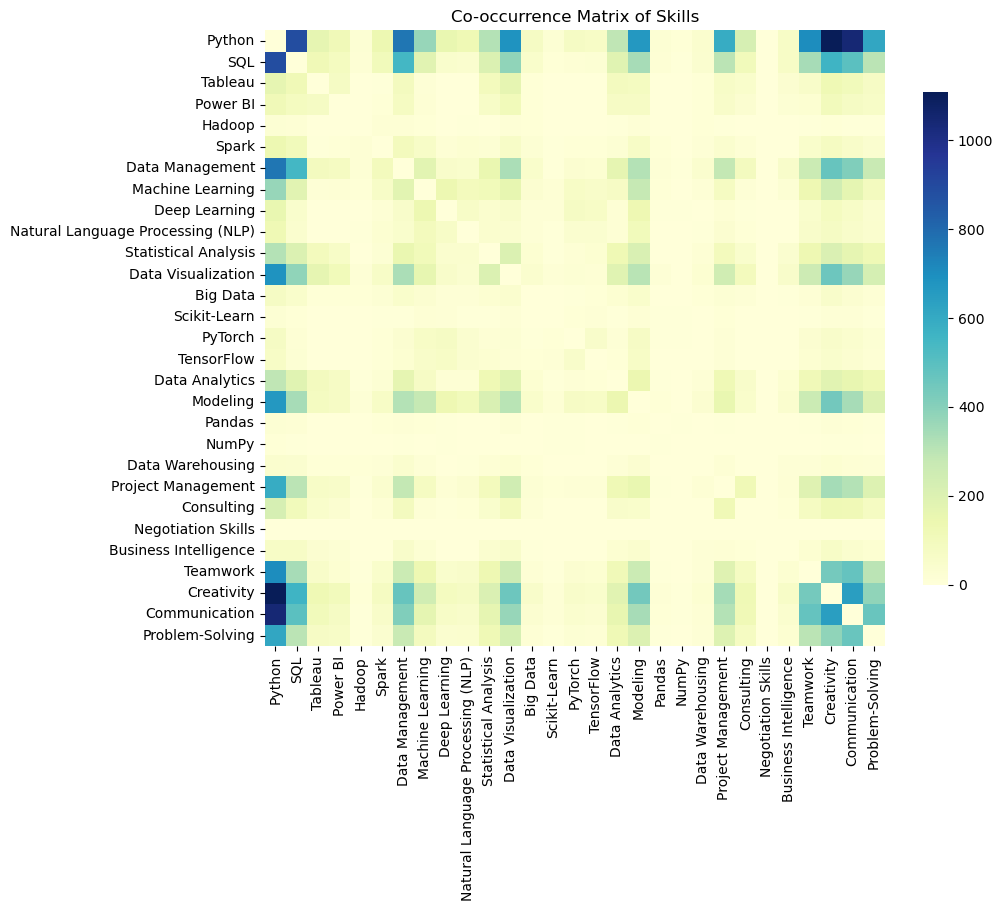

In [16]:
# Figure 2: A co-occurrence matrix plot for skills
import seaborn as sns

# Re-compute the co-occurrence matrix and set the diagonal values to zero
co_occurrence_matrix = df_summary.T.dot(df_summary)
np.fill_diagonal(co_occurrence_matrix.values, 0)

# Plot the co-occurrence matrix
plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence_matrix, annot=False, cmap="YlGnBu", cbar_kws={'shrink': .8})
plt.title('Co-occurrence Matrix of Skills')
plt.show()

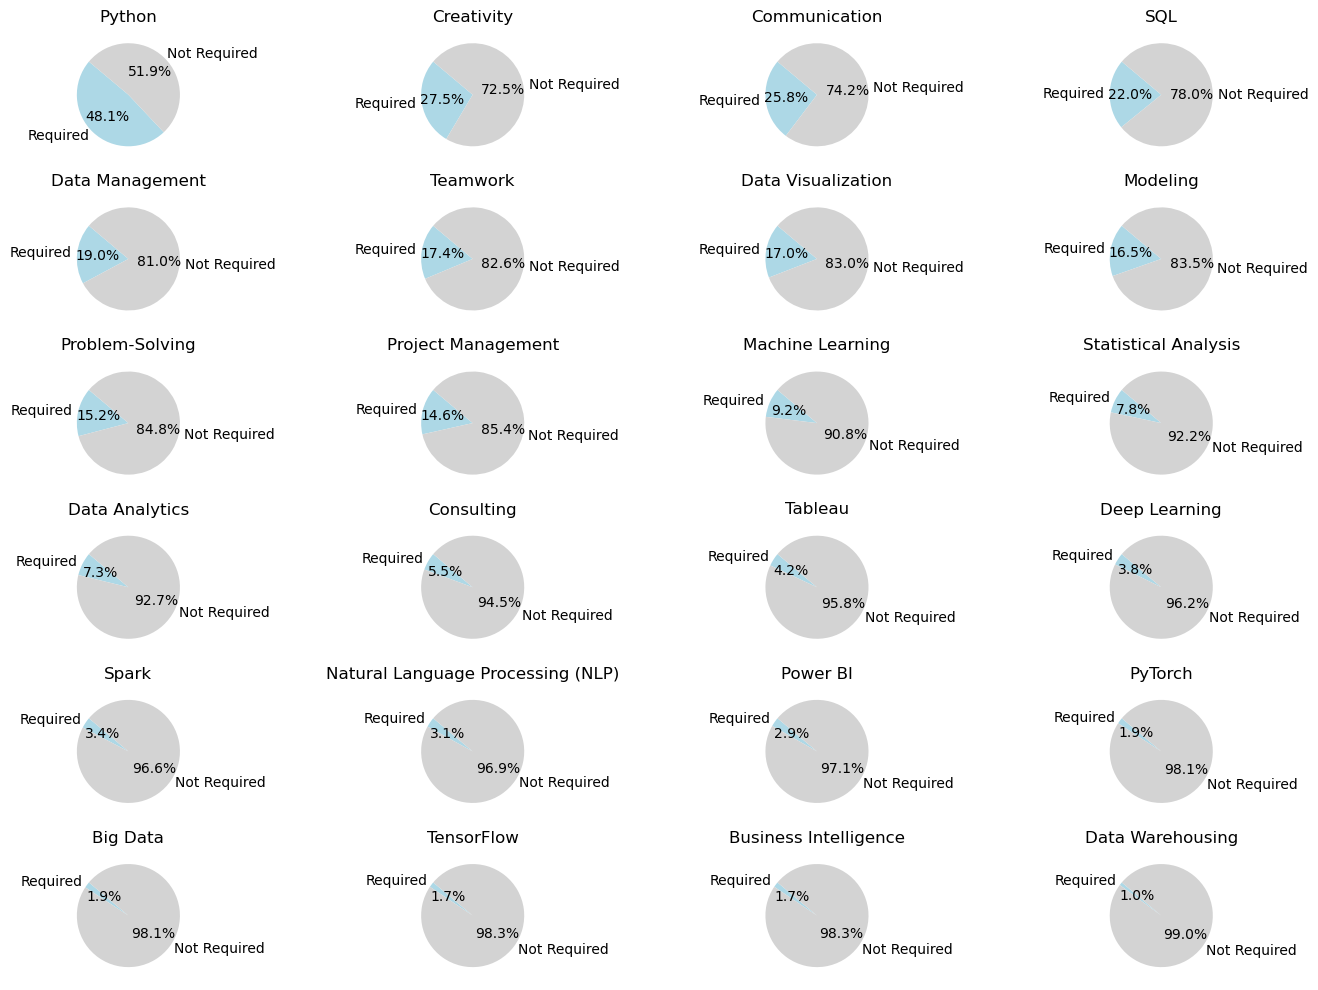

In [17]:
# Figure 3: A pie chart for each skill showing the proportion of job postings requiring that skill

# Define the figure size and layout
fig, axes = plt.subplots(6, 4, figsize=(14, 10))
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

# Loop through the dataframe columns and create a pie chart for each
for ax, (skill, count) in zip(axes, skill_counts.items()):
    ax.pie([count, len(df) - count], labels=['Required', 'Not Required'], autopct='%1.1f%%', startangle=140, colors=['lightblue', 'lightgray'])
    ax.set_title(skill)

# Hide any unused axes if the number of skills is not a multiple of the layout
for i in range(len(skill_counts), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


In [18]:
results['Salary'].notnull().sum()

results['Salary'][results['Salary'].notnull()]

0       $110,000 - $135,000 a year
1       $110,000 - $145,000 a year
2                $30 - $35 an hour
4         $74,677 - $81,134 a year
5       $140,000 - $150,000 a year
                   ...            
4009     $91,000 - $146,000 a year
4018     $90,800 - $125,200 a year
4024     $91,000 - $146,000 a year
4033     $90,800 - $125,200 a year
4039     $91,000 - $146,000 a year
Name: Salary, Length: 794, dtype: object

In [19]:
import re

# Function to clean and parse salary data
def parse_salary(salary):
    if pd.isnull(salary):
        return None

    # Define a full-time work year as 40 hours/week * 50 weeks/year
    full_time_hours_per_year = 40 * 50

    # Remove currency symbols and commas, and handle upper/lower case uniformly
    salary = salary.replace('$', '').replace(',', '').lower().strip()
    # Find numeric values
    numbers = re.findall(r'\d+', salary)

    # If the salary contains "up to" and "an hour"
    if 'up to' in salary and 'an hour' in salary and numbers:
        hourly_rate = float(numbers[0])
        # Calculate the annual equivalent of the hourly rate, in thousand dollar
        return hourly_rate * full_time_hours_per_year / 1000

    # If the salary is just an hourly rate without "up to"
    elif 'an hour' in salary and numbers:
        hourly_rate = float(numbers[0])
        return hourly_rate * full_time_hours_per_year / 1000

    # If the salary contains a range
    elif '-' in salary and numbers:
        # Calculate the average of the range, in thousand dollar
        salary_range = [float(value) for value in numbers[:2]]  # Assume first two are the range values
        return (sum(salary_range) / len(salary_range)) / 1000

    # If the salary is a single number, it could be a yearly salary
    elif numbers:
        # Convert the first found number to float and assume it is yearly salary
        return float(numbers[0]) / 1000

    return None  # In case of any other format that isn't covered


In [20]:
salary_df = results.copy()

# Apply the parsing function to the salary column
salary_df['Parsed Salary'] = salary_df['Salary'].apply(parse_salary)

# Drop the rows where 'Parsed Salary' is NaN because we cannot visualize them
salary_df = salary_df.dropna(subset=['Parsed Salary'])

# Display the cleaned and parsed salary dataframe
salary_df[['Title', 'Location', 'Parsed Salary']]

,Title,Location,Parsed Salary
0,Python Developer,Remote,122.5000
1,Software Engineer (Python & PySpark),Remote,127.5000
2,Entry Level Technician,Remote,60.0000
4,Data Analyst - OPT EAD only (No H1B's),Remote,77.9055
5,Software Engineer (Remote) - Network Protocols...,Remote,145.0000
...,...,...,...
4009,Senior Actuarial Analyst - Tri-State P&C (remote),"Remote in New York, NY 10119",118.5000
4018,Data Insights Analyst II,Remote,108.0000
4024,Senior Actuarial Analyst - Tri-State P&C (remote),"Remote in New York, NY 10119",118.5000
4033,Data Insights Analyst II,Remote,108.0000


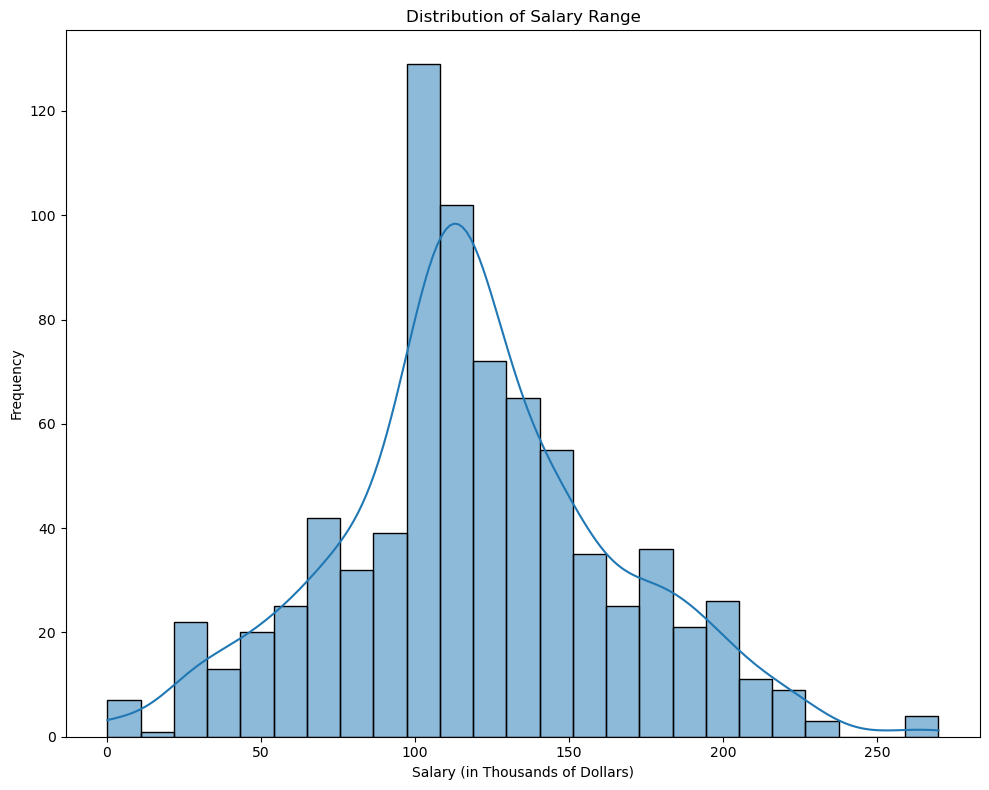

In [21]:
# Figure 4: Create a Histogram for (Parsed) Salary Range
plt.figure(figsize=(10, 8))
sns.histplot(data=salary_df['Parsed Salary'].dropna(), kde=True)
plt.title('Distribution of Salary Range')
plt.xlabel('Salary (in Thousands of Dollars)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

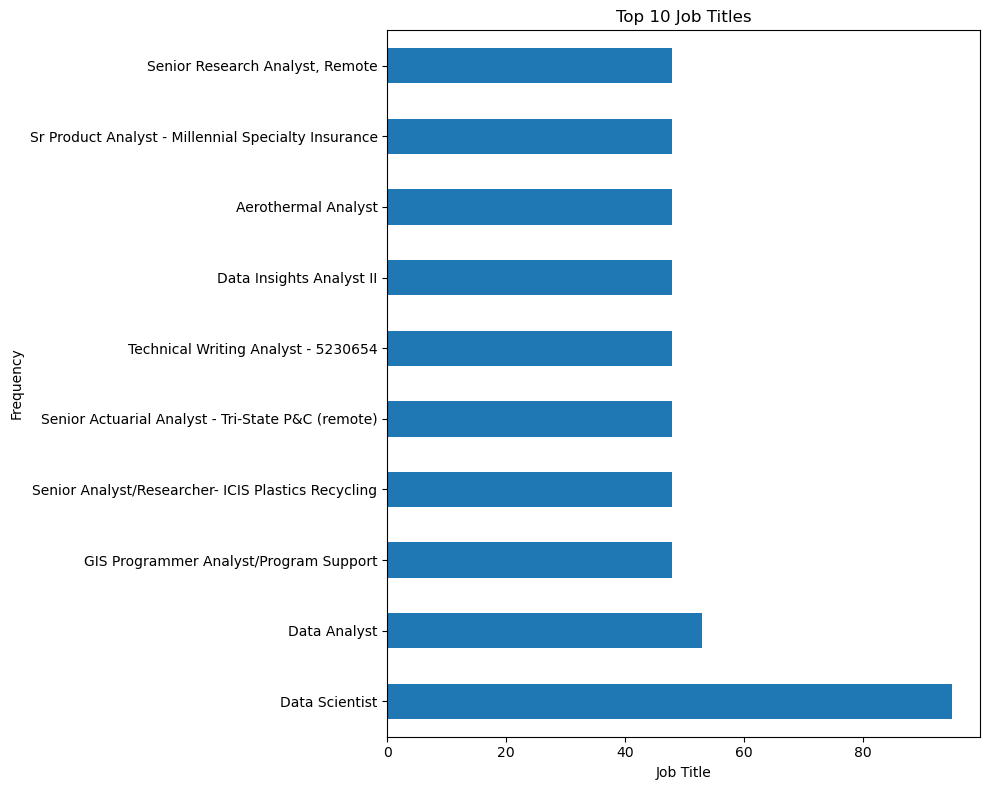

In [22]:
# Figure 5: A horizontal bar chart for top 10 job titles

plt.figure(figsize=(10, 8))
res['Title'].value_counts().nlargest(10).plot(kind='barh')
plt.title('Top 10 Job Titles')
plt.ylabel('Frequency')
plt.xlabel('Job Title')
plt.tight_layout()
plt.show()

In [27]:
!pip install wordcloud

     ---------------------------------------- 0.0/300.6 kB ? eta -:--:--
     -------------------------------------- 300.6/300.6 kB 6.2 MB/s eta 0:00:00


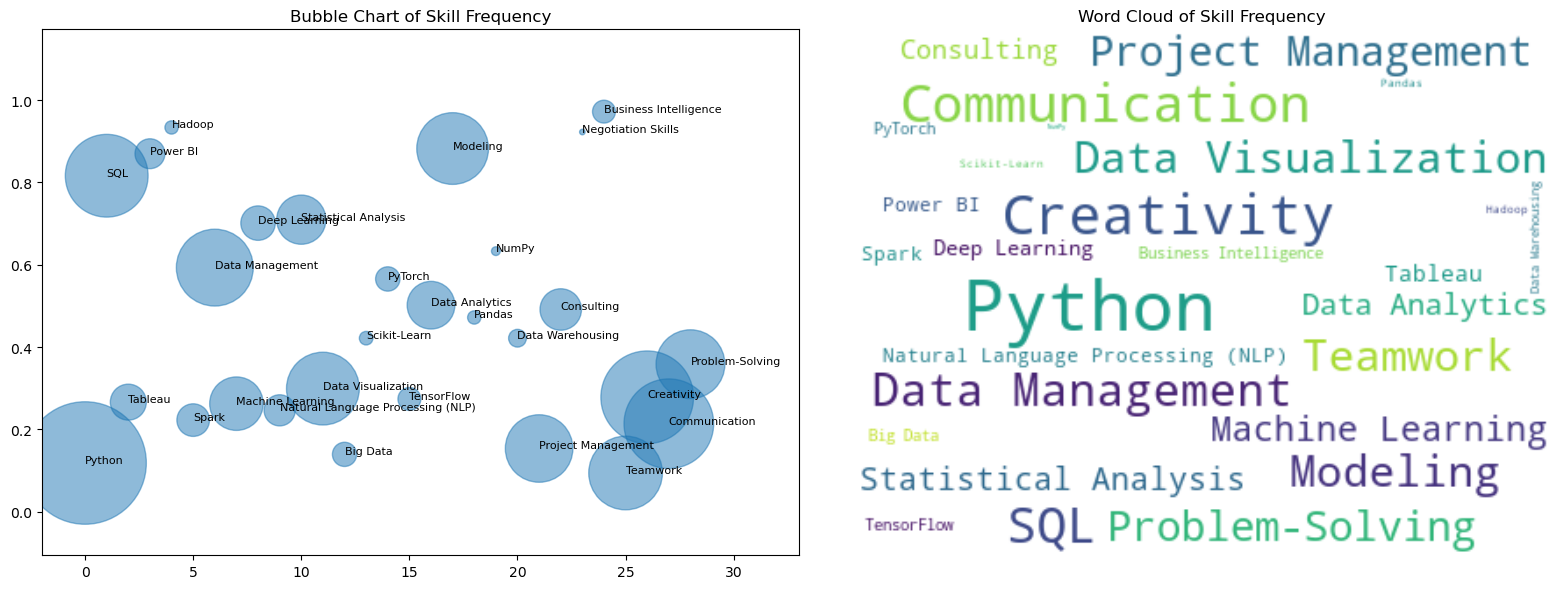

In [28]:
# Figure 6: A bubble chart for frequency of skills
# Figure 7: A word cloud for frequency of skills

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Generate random x, y coordinates for each skill
skills_freq = df_summary.sum()
x = np.arange(len(skills_freq))
y = np.random.rand(len(skills_freq))

# Scale the bubbles according to frequency, with a multiplier for visibility
sizes = skills_freq * 4  # Adjust to scale the bubbles

# Create the subplot container
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Bubble chart on the first subplot
ax[0].scatter(x, y, s=sizes, alpha=0.5)
for i, txt in enumerate(skills_freq.index):
    ax[0].annotate(txt, (x[i], y[i]), fontsize=8)
ax[0].set_title('Bubble Chart of Skill Frequency')
ax[0].set_xlim(min(x)-2, max(x)+5)
ax[0].set_ylim(min(y)-0.2, max(y)+0.2)

# Create a word cloud for the second subplot
skills_frequency = skills_freq.to_dict()
wordcloud = WordCloud(width=400, height=300, background_color='white', max_font_size=40).generate_from_frequencies(skills_frequency)

# Word cloud on the second subplot
ax[1].imshow(wordcloud, interpolation='bilinear')
ax[1].set_title('Word Cloud of Skill Frequency')
ax[1].axis('off')

# Display the plots side by side
plt.tight_layout()
plt.show()


# Hierarchical clustering implementation

In [29]:
print(a.shape)
print(a) # a is the 2D array for skill occurences
print(np.count_nonzero(a == 0) / (a.shape[0]*a.shape[1])) # Count the number of zeros in the matrix
df_summary.head() # df_summary is the dataframe for skill occurences

(4041, 29)
[[1 1 0 ... 1 1 0]
 [1 0 0 ... 1 1 1]
 [1 0 0 ... 0 1 1]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
0.903267371510978


,Python,SQL,Tableau,Power BI,Hadoop,Spark,Data Management,Machine Learning,Deep Learning,Natural Language Processing (NLP),...,NumPy,Data Warehousing,Project Management,Consulting,Negotiation Skills,Business Intelligence,Teamwork,Creativity,Communication,Problem-Solving
0,1,1,0,0,0,1,1,1,0,0,...,0,0,1,0,0,0,0,1,1,0
1,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,1,1,1
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,1
3,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,1,1,1
4,1,1,1,1,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0


[]

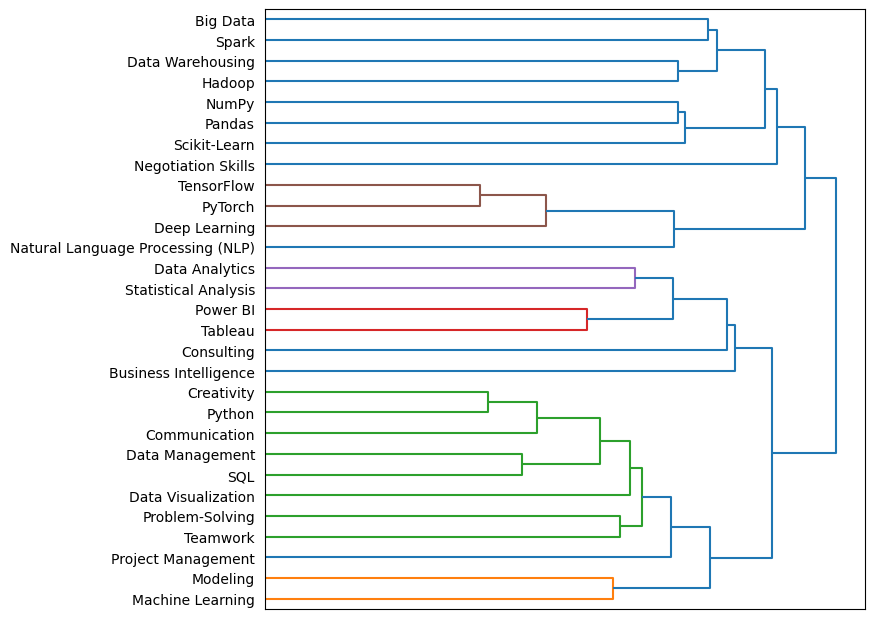

In [30]:
# Step 1: Generate a distance matrix to describe the relationship between skills

# Create empty matrix to fill
# D = np.zeros([a.shape[1],a.shape[1]])

# Initialize matrices for intersection (co-occurrence) and union
intersection = np.zeros((a.shape[1], a.shape[1]))
union = np.zeros((a.shape[1], a.shape[1]))

# Find all element-wise skill proximities (distances)
for k in range(a.shape[0]): # For each job posting
    for i in range(a.shape[1]): # For each skill
        for j in range(a.shape[1]): # For each skill
            # Calculate proximities
            if a[k, i] == 1 and a[k, j] == 1:  # Both skills are present in the job posting
                intersection[i, j] += 1
                intersection[j, i] += 1  # Symmetric
            if a[k, i] == 1 or a[k, j] == 1:  # Either of the skills is present
                union[i, j] += 1
                union[j, i] += 1  # Symmetric

# Calculate Jaccard distance matrix
# Jaccard distance = 1 - (intersection / union)
# To avoid division by zero, ensure union is not zero (it shouldn't be, given the calculation method)
# Jaccard distance is suitable here:
# Jaccard distance is designed for binary data, effectively measures how dissimilar two sets are
# Given the high sparsity of our data (70.5% 0s), the Jaccard distance is advantageous because it disregards the matching 0s when calculating dissimilarity.
jaccard_distance = 1 - (intersection / union)

# Since Jaccard distance for identical items (self-comparison) should be 0, indicating no dissimilarity, we can correct the diagonal
np.fill_diagonal(jaccard_distance, 0)

# Step 2: Perform hierarchical clustering of skills
# 'average' linkage can be suitable here:
# It is suitable for clustering binary, sparse data because it balances cluster sizes by considering the average distances between
# all pairs of observations in two clusters, offering a middle-ground approach that mitigates the extremes seen in single and complete linkage methods.
# This methodology reflects the overall similarity between clusters more comprehensively, making it particularly useful for developing a well-rounded educational curriculum
# by ensuring that courses cover areas that are broadly related.
Y = sch.linkage(jaccard_distance, method='average')

# Step 3: Generate a dendrogram
fig = plt.figure(figsize=(15,10))
ax = fig.add_axes([0.1,0.1,0.4,0.6])

Z = sch.dendrogram(Y, orientation='right')
labels = df_summary.columns[Z['leaves']]
ax.set_xticks([])
ax.set_yticklabels(labels)

plt.savefig('dendrogram.png', format='png', bbox_inches='tight')
plt.plot()


# Print clusters after slicing dendrogram

[]

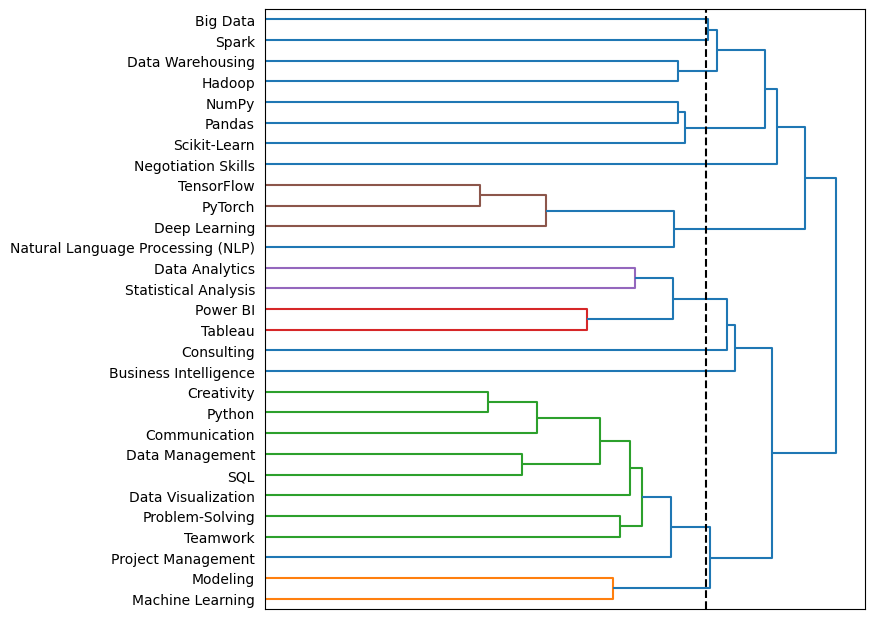

In [31]:
## Cutting the dendrogram at max_d
max_d = 1.25 #??

fig = plt.figure(figsize=(15,10))
ax = fig.add_axes([0.1,0.1,0.4,0.6])

Z = sch.dendrogram(Y, orientation='right')
labels = df_summary.columns[Z['leaves']]
ax.set_xticks([])
ax.set_yticklabels(labels)

# Cutting the dendrogram at max_d
plt.axvline(x=max_d*jaccard_distance.max(), c='k', linestyle='--')

plt.plot()

In [32]:
## Identify clusters with max_d cut

lbs = sch.fcluster(Y, max_d*jaccard_distance.max(), 'distance')
clustr = lbs[Z['leaves']]

clust_skls = {}
for k in list(set(clustr)):
    clust_skls[k] = []

for j in range(len(labels)):
    clust_skls[clustr[j]].append(labels[j])

In [33]:
for key, value in clust_skls.items():
    print(key, value)

1 ['Machine Learning', 'Modeling']
2 ['Project Management', 'Teamwork', 'Problem-Solving', 'Data Visualization', 'SQL', 'Data Management', 'Communication', 'Python', 'Creativity']
3 ['Tableau', 'Power BI', 'Statistical Analysis', 'Data Analytics']
4 ['Consulting']
5 ['Business Intelligence']
6 ['Natural Language Processing (NLP)', 'Deep Learning', 'PyTorch', 'TensorFlow']
7 ['Scikit-Learn', 'Pandas', 'NumPy']
8 ['Hadoop', 'Data Warehousing']
9 ['Spark']
10 ['Big Data']
11 ['Negotiation Skills']


In [34]:
print("Number of automatically created clusters:",len(clust_skls))

Number of automatically created clusters: 11


In [37]:
# Final 11 clusters for Hirarchical Clustering
clust_skills = {}

# Course 1: Foundational Programming and Data Analysis
clust_skills['Course 1'] = ['Machine Learning', 'Modeling']

# Course 2: Teamwork and Management Skills
clust_skills['Course 2'] = ['Project Management', 'Teamwork', 'Problem-Solving', 'Data Visualization', 'SQL', 'Data Management', 'Communication', 'Python', 'Creativity']

# Course 3: Introduction to Data Management and Basic Data Engineering
clust_skills['Course 3'] = ['Tableau', 'Power BI', 'Statistical Analysis', 'Data Analytics']

# Course 4: Core Data Science Libraries and Tools
clust_skills['Course 4'] = ['Consulting']

# Course 5: Advanced Data Engineering Techniques
clust_skills['Course 5'] = ['Business Intelligence']

# Course 6: Business Intelligence and Data Reporting
clust_skills['Course 6'] = ['Natural Language Processing (NLP)', 'Deep Learning', 'PyTorch', 'TensorFlow']

# Course 7: Specialization in Machine Learning and Deep Learning
clust_skills['Course 7'] = ['Scikit-Learn', 'Pandas', 'NumPy']

# Course 8: Advanced Business and Consulting Skills
clust_skills['Course 8'] = ['Hadoop', 'Data Warehousing']

# Course 9: 
clust_skills['Course 9'] = ['Spark']

# Course 10: 
clust_skills['Course 10'] = ['Big Data']

# Course 11: 
clust_skills['Course 11'] = ['Negotiation Skills']

len(clust_skills)
print("Number of manually adjusted clusters:",len(clust_skills))

for k, v in clust_skills.items():
    print(f'{k}: ' + ', '.join(clust_skills[k]))

Number of manually adjusted clusters: 11
Course 1: Machine Learning, Modeling
Course 2: Project Management, Teamwork, Problem-Solving, Data Visualization, SQL, Data Management, Communication, Python, Creativity
Course 3: Tableau, Power BI, Statistical Analysis, Data Analytics
Course 4: Consulting
Course 5: Business Intelligence
Course 6: Natural Language Processing (NLP), Deep Learning, PyTorch, TensorFlow
Course 7: Scikit-Learn, Pandas, NumPy
Course 8: Hadoop, Data Warehousing
Course 9: Spark
Course 10: Big Data
Course 11: Negotiation Skills


# K-means clustering implementation

In [38]:
import re

# Function to clean and parse salary data
def parse_annual_salary(salary):
    if pd.isnull(salary):
        return None

    # Define a full-time work year as 40 hours/week * 50 weeks/year
    full_time_hours_per_year = 40 * 50

    # Remove currency symbols and commas, and handle upper/lower case uniformly
    salary = salary.replace('$', '').replace(',', '').lower().strip()
    # Find numeric values
    numbers = re.findall(r'\d+', salary)

    # If the salary contains "up to" and "an hour"
    if 'up to' in salary and 'an hour' in salary and numbers:
        hourly_rate = float(numbers[0])
        return hourly_rate * full_time_hours_per_year

    # If the salary is just an hourly rate without "up to"
    elif 'an hour' in salary and numbers:
        hourly_rate = float(numbers[0])
        return hourly_rate * full_time_hours_per_year

    # If the salary contains a range
    elif '-' in salary and numbers:
        # If it's an hourly range, calculate the average
        if 'an hour' in salary:
            salary_range = [float(value) for value in numbers[:2]]  # Assume first two are the range values
            return (sum(salary_range) / len(salary_range)) * full_time_hours_per_year
        else:
            # For annual range, calculate the average and convert to hourly
            salary_range = [float(value) for value in numbers[:2]]  # Assume first two are the range values
            annual_average = sum(salary_range) / len(salary_range)
            return annual_average

    # If the salary is a single number, it could be a yearly salary
    elif numbers:
        # Convert the first found number to float and assume it is yearly salary
        yearly_salary = float(numbers[0])

        return yearly_salary

    return None  # In case of any other format that isn't covered


# Feature engineering

In [39]:
skills = list(sskills.keys()) + list(tskills.keys()) + list(bskills.keys()) + list(pskills.keys())
skill_features_df = pd.DataFrame(skills, columns=['Skill'])

# Categorize skills into hard skills and soft skills
hard_skills = ["Python", "SQL", "Tableau", "Power BI", "Hadoop", "Spark", "Data Management",
               "Machine Learning", "Deep Learning", "Natural Language Processing (NLP)",
               "Statistical Analysis", "Data Visualization", "Big Data", "Scikit-Learn",
               "PyTorch", "TensorFlow", "Data Analytics", "Modeling", "Pandas", "NumPy",
               "Data Warehousing", "Business Intelligence"]

soft_skills = ["Project Management", "Consulting", "Negotiation Skills", "Teamwork",
               "Creativity", "Communication", "Problem-Solving"]


In [40]:
# Feature 1: Skill Frequency
skill_frequency = df_summary.sum()

# Now merge the skill frequency data with the skill_features_df based on the 'Skill' column
skill_features_df = skill_features_df.merge(skill_frequency.to_frame(name='Skill Frequency'),
                                            left_on='Skill', right_index=True, how='left')

skill_features_df.head()

,Skill,Skill Frequency
0,Python,1945
1,SQL,888
2,Tableau,168
3,Power BI,116
4,Hadoop,23


In [47]:
# Feature 2: Average Annual Salary and Feature 3: Highest Annual Salary for Skill

df1 = results[['Title', 'Company', 'Location', 'Salary']].copy()
df2 = pd.DataFrame(sskills)
df3 = pd.DataFrame(tskills)
df4 = pd.DataFrame(bskills)
df5 = pd.DataFrame(pskills)
frames = [df1, df2, df3, df4, df5]
salary_skills_df = pd.concat(frames, axis = 1)

# Parse the salary information to handle ranges and formats
salary_skills_df['Annual Salary'] = salary_skills_df['Salary'].apply(parse_annual_salary)
# Calculate the average, max, min annual salary for each skill
average_salaries = {}
highest_salaries = {}
# lowest_salaries = {}
for skill in skills:
    # Filter the dataframe for job postings that mention the skill
    skill_df = salary_skills_df[(salary_skills_df[skill]== '1') & (~salary_skills_df['Annual Salary'].isna())]
    # Calculate the average salary for these postings
    average_salaries[skill] = round(skill_df['Annual Salary'].mean(), 2)
    highest_salaries[skill] = round(skill_df['Annual Salary'].max(), 2)
    #highest_salaries[skill] = round(max(skill_df['Annual Salary']), 2)
    # lowest_salaries[skill] = round(min(skill_df['Annual Salary']), 2)

# Convert the average salaries dictionary to a DataFrame
average_salary_df = pd.DataFrame(list(average_salaries.items()), columns=['Skill', 'Average Annual Salary'])
highest_salary_df = pd.DataFrame(list(highest_salaries.items()), columns=['Skill', 'Highest Annual Salary'])
# lowest_salary_df = pd.DataFrame(list(lowest_salaries.items()), columns=['Skill', 'Lowest Annual Salary'])

merged_df = pd.merge(average_salary_df, highest_salary_df, on='Skill')
# merged_df = pd.merge(merged_df, lowest_salary_df, on='Skill')

# Merge this DataFrame with the salary_skills_df
# This will add the average salary for each skill as a new column in salary_skills_df
skill_features_df = skill_features_df.merge(merged_df, on='Skill', how='left')

skill_features_df.head()

,Skill,Skill Frequency,Average Annual Salary,Highest Annual Salary
0,Python,1945,121741.00,230325.0
1,SQL,888,116711.45,225000.0
2,Tableau,168,103337.13,152500.0
3,Power BI,116,101239.11,230325.0
4,Hadoop,23,171000.00,200000.0


In [48]:
# Feature 4: Number of unique companies

# Initialize a dictionary to store the count of unique companies for each skill
unique_companies_per_skill = {skill: set() for skill in skills}

# Iterate over each row and update the set of unique companies for each skill
for index, row in res.iterrows():
    for skill in unique_companies_per_skill.keys():
        if row[skill] == '1':  # If the skill is present
            unique_companies_per_skill[skill].add(row['Company'])

# Calculate the number of unique companies for each skill
num_unique_companies_per_skill = {skill: len(companies) for skill, companies in unique_companies_per_skill.items()}

# Convert this to a DataFrame
unique_companies_df = pd.DataFrame(list(num_unique_companies_per_skill.items()), columns=['Skill', ' Number of unique companies'])

skill_features_df = skill_features_df.merge(unique_companies_df, on='Skill', how='left')

skill_features_df.head()

,Skill,Skill Frequency,Average Annual Salary,Highest Annual Salary,Number of unique companies
0,Python,1945,121741.00,230325.0,672
1,SQL,888,116711.45,225000.0,343
2,Tableau,168,103337.13,152500.0,62
3,Power BI,116,101239.11,230325.0,49
4,Hadoop,23,171000.00,200000.0,10


In [49]:
# Feature 5: Number of unique job titles

# Initialize a dictionary to store the count of unique job titles for each skill
unique_titles_per_skill = {skill: set() for skill in skills}

# Iterate over each row and update the set of unique job titles for each skill
for index, row in res.iterrows():
    for skill in unique_titles_per_skill:
        if row[skill] == '1':  # If the skill is present
            unique_titles_per_skill[skill].add(row['Title'])

# Calculate the number of unique job titles for each skill
num_unique_titles_per_skill = {skill: len(titles) for skill, titles in unique_titles_per_skill.items()}

# Convert this to a DataFrame
unique_titles_df = pd.DataFrame(list(num_unique_titles_per_skill.items()), columns=['Skill', 'Number of unique job titles'])

skill_features_df = skill_features_df.merge(unique_titles_df, on='Skill', how='left')

skill_features_df.head()

,Skill,Skill Frequency,Average Annual Salary,Highest Annual Salary,Number of unique companies,Number of unique job titles
0,Python,1945,121741.00,230325.0,672,692
1,SQL,888,116711.45,225000.0,343,323
2,Tableau,168,103337.13,152500.0,62,63
3,Power BI,116,101239.11,230325.0,49,46
4,Hadoop,23,171000.00,200000.0,10,8


In [50]:
# Feature 6: Number of times 'Certificate' is mentioned in descriptions where this skill is mentioned

# Iterate over each skill column and count the number of times 'Certificate' is mentioned in the job descriptions
for skill in skills:
    # Filter the rows where the skill is present
    descriptions_with_skill = res.loc[res[skill] == '1', 'Descriptions']

    # Count occurrences of 'Certificate' in those descriptions
    certificate_count = descriptions_with_skill.str.contains('certificate', case=False, na=False).sum()

    # Add the count to the corresponding skill in the skill_features_df
    skill_features_df.loc[skill_features_df['Skill'] == skill, 'Certificate Mentions'] = certificate_count

skill_features_df.head()

,Skill,Skill Frequency,Average Annual Salary,Highest Annual Salary,Number of unique companies,Number of unique job titles,Certificate Mentions
0,Python,1945,121741.00,230325.0,672,692,31.0
1,SQL,888,116711.45,225000.0,343,323,6.0
2,Tableau,168,103337.13,152500.0,62,63,0.0
3,Power BI,116,101239.11,230325.0,49,46,0.0
4,Hadoop,23,171000.00,200000.0,10,8,0.0


In [51]:
# Feature 7: Average level of education level mentioned

# Mapping of education levels to a numerical scale for averaging
education_levels = {
    'high school': 1,
    'associate': 2,
    'bachelor': 3,
    'master': 4,
    'phd': 5,
    'doctorate': 5 # Equating PhD and doctorate for simplicity
}

# Initialize a dictionary to store the sum of education levels and counts for each skill
education_sum_count_per_skill = {skill: {'sum': 0, 'count': 0} for skill in skills}

# Iterate over each row in the DataFrame
for _, row in res.iterrows():
    for skill in education_sum_count_per_skill.keys():
        if row[skill] == '1':  # If the skill is present
            # Look for education level keywords in the description
            for level, rank in education_levels.items():
                if level in row['Descriptions'].lower():
                    education_sum_count_per_skill[skill]['sum'] += rank
                    education_sum_count_per_skill[skill]['count'] += 1
                    break  # Break after finding the first match since we only count one level per description

# Calculate the average education level for each skill
average_education_per_skill = {skill: data['sum'] / data['count'] if data['count'] != 0 else None
                               for skill, data in education_sum_count_per_skill.items()}

# Convert the averages to a DataFrame
average_education_df = pd.DataFrame(list(average_education_per_skill.items()), columns=['Skill', 'Average Education Level'])

skill_features_df = skill_features_df.merge(average_education_df, on='Skill', how='left')

skill_features_df.head()


,Skill,Skill Frequency,Average Annual Salary,Highest Annual Salary,Number of unique companies,Number of unique job titles,Certificate Mentions,Average Education Level
0,Python,1945,121741.00,230325.0,672,692,31.0,2.871389
1,SQL,888,116711.45,225000.0,343,323,6.0,2.826772
2,Tableau,168,103337.13,152500.0,62,63,0.0,2.763359
3,Power BI,116,101239.11,230325.0,49,46,0.0,2.707071
4,Hadoop,23,171000.00,200000.0,10,8,0.0,2.714286


In [52]:
# Feature 8: Highest level of education level mentioned

# Initialize a dictionary to store the highest education level found for each skill
highest_education_level_per_skill = {skill: 0 for skill in skills}

# Iterate over each row in the DataFrame
for _, row in res.iterrows():
    for skill in highest_education_level_per_skill:
        if row[skill] == '1':  # If the skill is present
            # Find the highest education level mentioned in the description
            for level, value in education_levels.items():
                if level in row['Descriptions'].lower():
                    highest_education_level_per_skill[skill] = max(highest_education_level_per_skill[skill], value)

# Convert the dictionary to a DataFrame
highest_education_level_df = pd.DataFrame(list(highest_education_level_per_skill.items()), columns=['Skill', 'Highest Education Level'])

# Merge this DataFrame with the skill_features_df DataFrame
skill_features_df = skill_features_df.merge(highest_education_level_df, on='Skill', how='left')

skill_features_df.head()

,Skill,Skill Frequency,Average Annual Salary,Highest Annual Salary,Number of unique companies,Number of unique job titles,Certificate Mentions,Average Education Level,Highest Education Level
0,Python,1945,121741.00,230325.0,672,692,31.0,2.871389,5
1,SQL,888,116711.45,225000.0,343,323,6.0,2.826772,5
2,Tableau,168,103337.13,152500.0,62,63,0.0,2.763359,5
3,Power BI,116,101239.11,230325.0,49,46,0.0,2.707071,4
4,Hadoop,23,171000.00,200000.0,10,8,0.0,2.714286,4


In [53]:
# Feature 9: Average job level 'entry' vs. 'associate', 'senior', etc
job_levels = {
    'intern': 1,
    'entry': 2,
    'junior': 3,
    'associate': 4,
    'mid': 5,
    'senior': 6,
    'lead': 7,
    'manager': 8,
    'director': 9,
    'chief': 10
}

# Initialize a dictionary to store total job level scores and count for each skill
job_level_scores_per_skill = {skill: {'total': 0, 'count': 0} for skill in skills}

# Iterate over each row in the DataFrame
for _, row in res.iterrows():
    for skill in job_level_scores_per_skill:
        if row[skill] == '1':  # If the skill is present
            # Check the job title for each job level and update the score and count
            for job_level, level_score in job_levels.items():
                if job_level in row['Title'].lower():
                    job_level_scores_per_skill[skill]['total'] += level_score
                    job_level_scores_per_skill[skill]['count'] += 1
                    break  # Assuming only one job level per title

# Calculate the average job level for each skill
for skill, data in job_level_scores_per_skill.items():
    if data['count'] > 0:
        job_level_scores_per_skill[skill] = data['total'] / data['count']
    else:
        job_level_scores_per_skill[skill] = None  # If no job levels were found for this skill

# Convert the dictionary to a DataFrame
average_job_level_df = pd.DataFrame(list(job_level_scores_per_skill.items()), columns=['Skill', 'Average Job Level'])

skill_features_df = skill_features_df.merge(average_job_level_df, on='Skill', how='left')

skill_features_df.head()


,Skill,Skill Frequency,Average Annual Salary,Highest Annual Salary,Number of unique companies,Number of unique job titles,Certificate Mentions,Average Education Level,Highest Education Level,Average Job Level
0,Python,1945,121741.00,230325.0,672,692,31.0,2.871389,5,6.253259
1,SQL,888,116711.45,225000.0,343,323,6.0,2.826772,5,6.248175
2,Tableau,168,103337.13,152500.0,62,63,0.0,2.763359,5,6.980769
3,Power BI,116,101239.11,230325.0,49,46,0.0,2.707071,4,6.970588
4,Hadoop,23,171000.00,200000.0,10,8,0.0,2.714286,4,6.000000


In [54]:
# Feature 10: Average number of soft skills co-occurred

# Calculate the sum of soft skills for each row (job posting)
res['Soft Skill Count'] = res[soft_skills].astype(int).sum(axis=1)

# Initialize a dictionary to hold the total soft skill counts and the number of occurrences for each skill
soft_skill_cooccurrence = {skill: {'total_count': 0, 'occurrences': 0} for skill in skills}

# Iterate over each row and skill
for _, row in res.iterrows():
    for skill in skills:
        if row[skill] == '1':  # If the skill is present
            # Add the count of soft skills in this row to the total count for the skill
            soft_skill_cooccurrence[skill]['total_count'] += row['Soft Skill Count']
            # Increment the occurrences count
            soft_skill_cooccurrence[skill]['occurrences'] += 1

# Calculate the average number of soft skills co-occurred for each skill
for skill in skills:
    if soft_skill_cooccurrence[skill]['occurrences'] > 0:
        average_cooccur = soft_skill_cooccurrence[skill]['total_count'] / soft_skill_cooccurrence[skill]['occurrences']
    else:
        average_cooccur = 0
    soft_skill_cooccurrence[skill] = average_cooccur

# Convert the results to a DataFrame
average_cooccur_df = pd.DataFrame(list(soft_skill_cooccurrence.items()), columns=['Skill', 'Average Number of Soft Skills Co-occurred'])

# Merge this DataFrame with the skill_features_df on 'Skill'
skill_features_df = skill_features_df.merge(average_cooccur_df, on='Skill', how='left')

skill_features_df.head()


,Skill,Skill Frequency,Average Annual Salary,Highest Annual Salary,Number of unique companies,Number of unique job titles,Certificate Mentions,Average Education Level,Highest Education Level,Average Job Level,Average Number of Soft Skills Co-occurred
0,Python,1945,121741.00,230325.0,672,692,31.0,2.871389,5,6.253259,2.202571
1,SQL,888,116711.45,225000.0,343,323,6.0,2.826772,5,6.248175,2.372748
2,Tableau,168,103337.13,152500.0,62,63,0.0,2.763359,5,6.980769,2.863095
3,Power BI,116,101239.11,230325.0,49,46,0.0,2.707071,4,6.970588,3.043103
4,Hadoop,23,171000.00,200000.0,10,8,0.0,2.714286,4,6.000000,1.652174


In [55]:
# Feature 11: Average number of hard skills co-occurred

# Calculate the sum of hard skills for each row (job posting)
df['Hard Skill Count'] = df[hard_skills].astype(int).sum(axis=1)

# Initialize dictionaries to store total counts and occurrences for hard skill co-occurrence
hard_skill_cooccur_counts = {skill: {'hard_skill_sum': 0, 'occurrences': 0} for skill in skills}

# Iterate over each job posting
for _, row in df.iterrows():
    for skill in skills:
        # Check if the skill is present in the job posting
        if row[skill] == '1':
            # Update the hard skill sum and occurrence count for the skill
            hard_skill_cooccur_counts[skill]['hard_skill_sum'] += row['Hard Skill Count']
            hard_skill_cooccur_counts[skill]['occurrences'] += 1

# Calculate the average number of hard skills co-occurred with each skill
for skill in skills:
    if hard_skill_cooccur_counts[skill]['occurrences'] > 0:
        avg_cooccur = hard_skill_cooccur_counts[skill]['hard_skill_sum'] / hard_skill_cooccur_counts[skill]['occurrences']
    else:
        avg_cooccur = 0  # Handle division by zero if the skill never occurs
    hard_skill_cooccur_counts[skill] = avg_cooccur

# Convert the results to a DataFrame for easier handling
average_hard_cooccur_df = pd.DataFrame(list(hard_skill_cooccur_counts.items()), columns=['Skill', 'Average Number of Hard Skills Co-occurred'])

# Merge this DataFrame with the skill_features_df on 'Skill'
skill_features_df = skill_features_df.merge(average_hard_cooccur_df, on='Skill', how='left')

skill_features_df.head()

,Skill,Skill Frequency,Average Annual Salary,Highest Annual Salary,Number of unique companies,Number of unique job titles,Certificate Mentions,Average Education Level,Highest Education Level,Average Job Level,Average Number of Soft Skills Co-occurred,Average Number of Hard Skills Co-occurred
0,Python,1945,121741.00,230325.0,672,692,31.0,2.871389,5,6.253259,2.202571,3.617481
1,SQL,888,116711.45,225000.0,343,323,6.0,2.826772,5,6.248175,2.372748,4.818694
2,Tableau,168,103337.13,152500.0,62,63,0.0,2.763359,5,6.980769,2.863095,6.886905
3,Power BI,116,101239.11,230325.0,49,46,0.0,2.707071,4,6.970588,3.043103,7.603448
4,Hadoop,23,171000.00,200000.0,10,8,0.0,2.714286,4,6.000000,1.652174,7.956522


In [56]:
# Set the 'Skill' column as the index of skill_features_df
skill_features_df = skill_features_df.set_index('Skill')
skill_features_df.index.name = None
print(skill_features_df.shape)
skill_features_df.head()

(29, 11)


,Skill Frequency,Average Annual Salary,Highest Annual Salary,Number of unique companies,Number of unique job titles,Certificate Mentions,Average Education Level,Highest Education Level,Average Job Level,Average Number of Soft Skills Co-occurred,Average Number of Hard Skills Co-occurred
Python,1945,121741.00,230325.0,672,692,31.0,2.871389,5,6.253259,2.202571,3.617481
SQL,888,116711.45,225000.0,343,323,6.0,2.826772,5,6.248175,2.372748,4.818694
Tableau,168,103337.13,152500.0,62,63,0.0,2.763359,5,6.980769,2.863095,6.886905
Power BI,116,101239.11,230325.0,49,46,0.0,2.707071,4,6.970588,3.043103,7.603448
Hadoop,23,171000.00,200000.0,10,8,0.0,2.714286,4,6.000000,1.652174,7.956522


In [57]:
skill_features_df.columns

Index(['Skill Frequency', 'Average Annual Salary', 'Highest Annual Salary',
       ' Number of unique companies', 'Number of unique job titles',
       'Certificate Mentions', 'Average Education Level',
       'Highest Education Level', 'Average Job Level',
       'Average Number of Soft Skills Co-occurred',
       'Average Number of Hard Skills Co-occurred'],
      dtype='object')

In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(skill_features_df)
scaled_features_df = pd.DataFrame(scaled_features, index=skill_features_df.index, columns=skill_features_df.columns)

scaled_features_df.shape

(29, 11)

# K-means elbow plot

In [60]:
# Check for missing values in the columns
missing_values = scaled_features_df.isnull().sum()

# Display the number of missing values for each column
missing_values

Skill Frequency                              0
Average Annual Salary                        1
Highest Annual Salary                        1
 Number of unique companies                  0
Number of unique job titles                  0
Certificate Mentions                         0
Average Education Level                      0
Highest Education Level                      0
Average Job Level                            1
Average Number of Soft Skills Co-occurred    0
Average Number of Hard Skills Co-occurred    0
dtype: int64

In [61]:
scaled_features_df = scaled_features_df.dropna(how='any',axis=0) 
# Check for missing values in the columns
missing_values = scaled_features_df.isnull().sum()
# Display the number of missing values for each column
missing_values

Skill Frequency                              0
Average Annual Salary                        0
Highest Annual Salary                        0
 Number of unique companies                  0
Number of unique job titles                  0
Certificate Mentions                         0
Average Education Level                      0
Highest Education Level                      0
Average Job Level                            0
Average Number of Soft Skills Co-occurred    0
Average Number of Hard Skills Co-occurred    0
dtype: int64

C:\Users\floro\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\floro\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\floro\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\floro\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Window

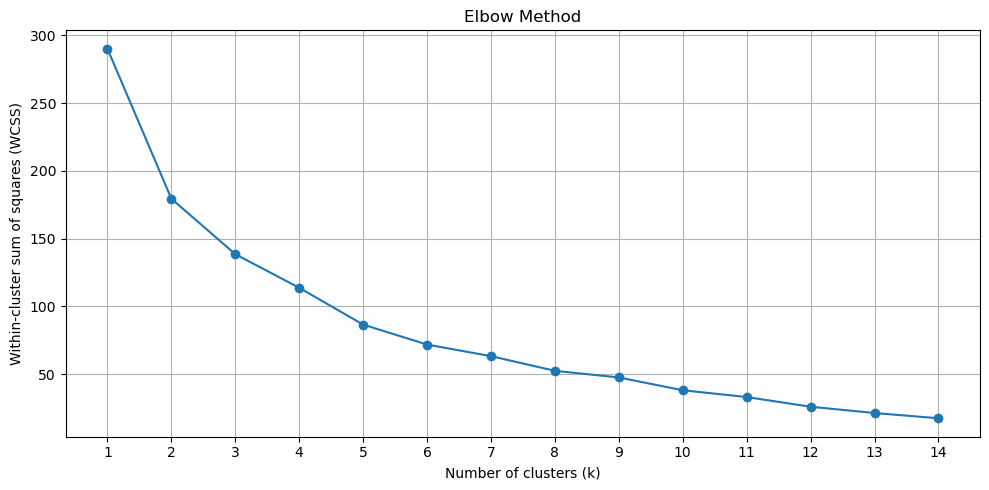

In [62]:
X = scaled_features_df.values  # Get all the numerical data from the DataFrame

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculate Within-cluster sum of squares (WCSS) errors for a range of k values
wcss = []
for i in range(1, 15):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the elbow graph
plt.figure(figsize=(10, 5))
plt.plot(range(1, 15), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within-cluster sum of squares (WCSS)')
plt.xticks(range(1, 15))
plt.grid(True)
plt.tight_layout()
plt.show()

# Decide on optimal K values and generate resulting course cirriculum (8-12 courses with 3 or more skills/topics each)

In [63]:
from sklearn.cluster import KMeans

# Define the number of clusters
k = 8

# Perform k-means clustering
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(scaled_features_df)

# Assign the cluster labels to each skill in the DataFrame
scaled_features_df['Cluster'] = kmeans.labels_

# Create a dictionary to build the curriculum from clusters
clust_skills_kmeans = {}
for cluster_num in range(k):
    # Filter the DataFrame to get skills in this cluster
    skills_in_cluster = scaled_features_df[scaled_features_df['Cluster'] == cluster_num].index.tolist()
    # Add to curriculum
    clust_skills_kmeans[f'Course {cluster_num + 1}'] = skills_in_cluster
    print(f'Course {cluster_num + 1}: {skills_in_cluster}')

# Create a DataFrame from the curriculum
clust_skills_kmeans_df = pd.DataFrame(dict([(k,pd.Series(v)) for k,v in clust_skills_kmeans.items()]))


C:\Users\floro\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Course 1: ['Project Management', 'Consulting', 'Teamwork', 'Problem-Solving']
Course 2: ['Spark', 'Machine Learning', 'Deep Learning', 'Natural Language Processing (NLP)', 'Statistical Analysis', 'Big Data', 'Data Analytics']
Course 3: ['Tableau', 'Power BI', 'Business Intelligence']
Course 4: ['Python']
Course 5: ['Scikit-Learn', 'PyTorch', 'TensorFlow', 'Pandas', 'NumPy']
Course 6: ['Hadoop']
Course 7: ['SQL', 'Data Management', 'Data Visualization', 'Modeling', 'Creativity', 'Communication']
Course 8: ['Data Warehousing']


# Generate a labeled scatterplot from K-means clustering

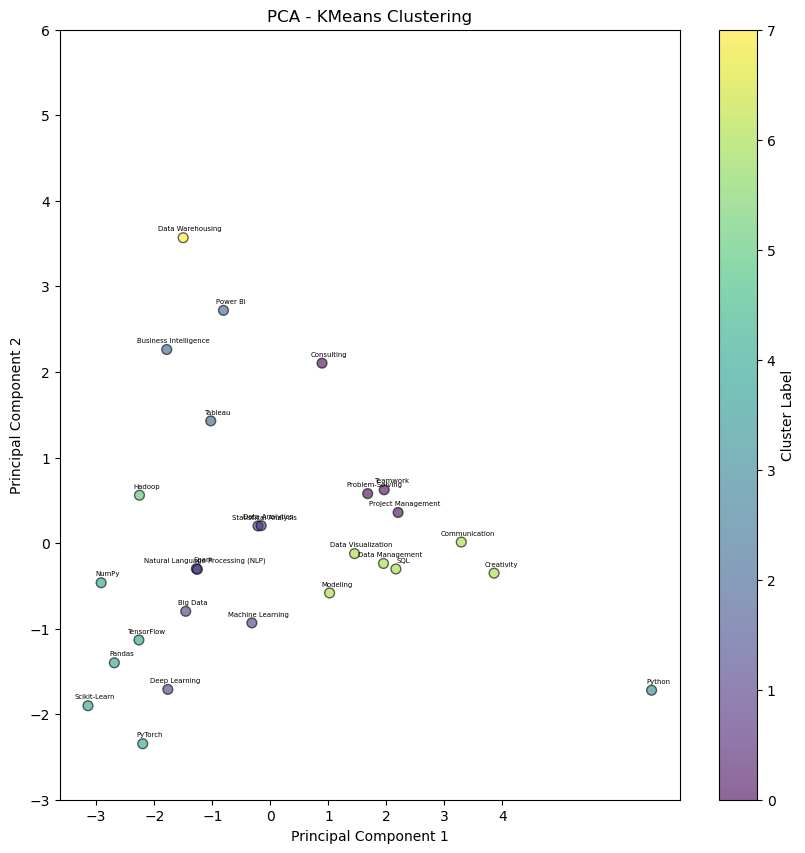

In [64]:
from sklearn.decomposition import PCA

# Perform PCA to reduce the data to two dimensions for visualization
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features_df.drop('Cluster', axis=1))

# Obtain cluster labels for color coding
cluster_labels = scaled_features_df['Cluster'].values

# Plot the scatter plot of the two principal components
plt.figure(figsize=(10, 10))
plt.scatter(principal_components[:, 0], principal_components[:, 1], c=cluster_labels, cmap='viridis', marker='o', edgecolor='black', s=50, alpha=0.6)

# Annotate the points with the skill names
for i, skill_name in enumerate(scaled_features_df.index):
    plt.annotate(skill_name, (principal_components[i, 0], principal_components[i, 1]), textcoords="offset points", xytext=(5,5), ha='center', fontsize=5)

plt.title('PCA - KMeans Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.xticks(range(-3, 5))
plt.yticks(range(-3, 7))
plt.colorbar(label='Cluster Label')
plt.show()

In [65]:
# Final 8 clusters for k-means Clustering
clust_skills_kmeans = {}

# Course 1: Foundational Programming and Data Analysis
clust_skills_kmeans['Course 1'] = ['Project Management', 'Consulting', 'Teamwork', 'Problem-Solving']

# Course 2: Teamwork and Management Skills
clust_skills_kmeans['Course 2'] = ['Spark', 'Machine Learning', 'Deep Learning', 'Natural Language Processing (NLP)', 'Statistical Analysis', 'Big Data', 'Data Analytics']

# Course 3: Introduction to Data Management and Basic Data Engineering
clust_skills_kmeans['Course 3'] = ['Tableau', 'Power BI', 'Business Intelligence']

# Course 4: Core Data Science Libraries and Tools
clust_skills_kmeans['Course 4'] = ['Python']

# Course 5: Advanced Data Engineering Techniques
clust_skills_kmeans['Course 5'] = ['Scikit-Learn', 'PyTorch', 'TensorFlow', 'Pandas', 'NumPy']

# Course 6: Business Intelligence and Data Reporting
clust_skills['Course 6'] = ['Hadoop']

# Course 7: Specialization in Machine Learning and Deep Learning
clust_skills['Course 7'] = ['SQL', 'Data Management', 'Data Visualization', 'Modeling', 'Creativity', 'Communication']

# Course 8: Advanced Business and Consulting Skills
clust_skills_kmeans['Course 8'] = ['Data Warehousing']

len(clust_skills_kmeans)
print("Number of manually adjusted clusters for k-means:",len(clust_skills))

for k, v in clust_skills_kmeans.items():
    print(f'{k}: ' + ', '.join(clust_skills_kmeans[k]))

Number of manually adjusted clusters for k-means: 11
Course 1: Project Management, Consulting, Teamwork, Problem-Solving
Course 2: Spark, Machine Learning, Deep Learning, Natural Language Processing (NLP), Statistical Analysis, Big Data, Data Analytics
Course 3: Tableau, Power BI, Business Intelligence
Course 4: Python
Course 5: Scikit-Learn, PyTorch, TensorFlow, Pandas, NumPy
Course 8: Data Warehousing


# Interpreting results with ChatGPT API

In [66]:
# Hierarchical clustering results
for k, v in clust_skills.items():
    print(f'{k}: {v}')

Course 1: ['Machine Learning', 'Modeling']
Course 2: ['Project Management', 'Teamwork', 'Problem-Solving', 'Data Visualization', 'SQL', 'Data Management', 'Communication', 'Python', 'Creativity']
Course 3: ['Tableau', 'Power BI', 'Statistical Analysis', 'Data Analytics']
Course 4: ['Consulting']
Course 5: ['Business Intelligence']
Course 6: ['Hadoop']
Course 7: ['SQL', 'Data Management', 'Data Visualization', 'Modeling', 'Creativity', 'Communication']
Course 8: ['Hadoop', 'Data Warehousing']
Course 9: ['Spark']
Course 10: ['Big Data']
Course 11: ['Negotiation Skills']


In [67]:
# Using Hierarchical clustering results
prompt1 = 'Write a short description of a course curriculum that contains 8 courses, each of which covers ' + \
f'several skills/topics. The potential skills/topics that will be covered in each course in this program will be like: {clust_skills}. ' + \
'For each course, note overview and audience for that course.' + \
'The description should entice potential students to enrol in this program.'

# Call OpenAI API for the prompt
response1 = client.chat.completions.create(
  model = model,
  messages = [
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt1}
  ]
)

# Develop a course curriculum - based on Hierarchical clustering results (with manual adjustments applied)
output1 = response1.choices[0].message.content
print(output1)


### Comprehensive Data Science & Analytics Program

Embark on an exciting journey through the fascinating world of data science and analytics with our comprehensive program designed for aspiring professionals. This meticulously curated curriculum is spread across 8 pivotal courses, each focusing on a cluster of essential skills and topics paramount to your success in the data science field. Whether you're aiming to become a data analyst, data scientist, business intelligence expert, or enter the burgeoning field of big data, our program offers the knowledge and hands-on experience needed to excel. Below is an overview of what each course offers:

#### Course 1: Introduction to Machine Learning and Modeling
- **Overview:** Dive into the fundamentals of machine learning, understand its importance in the modern world, and learn the art and science of modeling. 
- **Audience:** Ideal for beginners and professionals keen on grasping the core concepts of machine learning algorithms and their

In [68]:
# K-means clustering results
for k, v in clust_skills_kmeans.items():
    print(f'{k}: {v}')

Course 1: ['Project Management', 'Consulting', 'Teamwork', 'Problem-Solving']
Course 2: ['Spark', 'Machine Learning', 'Deep Learning', 'Natural Language Processing (NLP)', 'Statistical Analysis', 'Big Data', 'Data Analytics']
Course 3: ['Tableau', 'Power BI', 'Business Intelligence']
Course 4: ['Python']
Course 5: ['Scikit-Learn', 'PyTorch', 'TensorFlow', 'Pandas', 'NumPy']
Course 8: ['Data Warehousing']



Examining @/win-64::__win==0=0:  75%|#######5  | 3/4 [00:06<00:02,  2.30s/it]          
                                                                             

Examining conflict for python wordcloud:   0%|          | 0/4 [00:00<?, ?it/s]
                                                                              

UnsatisfiableError: The following specifications were found
to be incompatible with the existing python installation in your environment:

Specifications:

  - wordcloud=1.6.0 -> python[version='>=2.7,<2.8.0a0|>=3.8,<3.9.0a0|>=3.7,<3.8.0a0|>=3.6,<3.7.0a0']

Your python: python=3.9

If python is on the left-most side of the chain, that's the version you've asked for.
When python appears to the right, that indicates that the thing on the left is somehow
not available for the python version you are constrained to. Note that conda will not
change your python version to a different minor version unless you explicitly specify
that.


Note that strict channel priority may

Retrieving notices: ...working... done
Solving environment: ...working... unsuccessful initial attempt using frozen solve. Retrying with flexible solve.
Solving environment: ...working... unsuccessful initial attempt using frozen solve. Retrying with flexible solve.
Solving environment: ...working... 
Found conflicts! Looking for incompatible packages.
This can take several minutes.  Press CTRL-C to abort.
failed


In [ ]:
# Using K-means clustering results
prompt2 = 'Write a short description of a course curriculum that contains 8 courses, each of which covers ' + \
f'several skills/topics. The potential skills/topics that will be covered in each course in this program will be like: {clust_skills_kmeans}. ' + \
'For each course, note overview and audience for that course.' + \
'The description should entice potential students to enrol in this program.'

# Call OpenAI API for the prompt
response2 = client.chat.completions.create(
  model = model,
  messages = [
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt2}
  ]
)

# Develop a course curriculum - based on K-means clustering results
output2 = response2.choices[0].message.content
print(output2)